# MIMO_MTS_5G test on ZCU208
---

The following results were captured when looping back all 8 DACs to 8 ADCs through equal-length cables.

### Preparation from a PYNQ 3.0.1 image:

Run installation script: `./pynq_llrf/install.sh`.

In [1]:
%cd /home/xilinx/jupyter_notebooks/pynq_llrf/

/home/xilinx/jupyter_notebooks/pynq_llrf


In [2]:
import numpy as np
from mimo_mts.overlay import MimoMtsOverlay

%load_ext autoreload
%autoreload 2

In [3]:
ol = MimoMtsOverlay(config='ALS_MIMO5G_ZCU208')

Set DAC mixer: freq=0 MHz, nyquist=1, phase=0 degrees
Set ADC mixer: freq=0 MHz, nyquist=1, phase=0 degrees


# Configure trigger

internal, 10 Hz

In [4]:
ol.rf_control.register_map.trig_period = 250e5
ol.rf_control.register_map.trig_sel = 0
ol.rf_control.register_map.trig_delay = 0
ol.rf_control.register_map.trig_divide = 1
ol.rf_control.register_map.dac_enable = 1
ol.rf_control.register_map.pulse_length = 4095

# Generate Waveforms for Loopback

This overlay uses a single waveform memory that is broadcast to multiple DAC tiles.
The DAC accepts a stream of interleave I/Q samples.

In [5]:
fs = ol.adc_sampling_rate
fs_ghz = fs / 1e9
start = 1248 # start of the signal
print(f'Fs: {fs_ghz} GHz. RF loop back latency: {start/fs_ghz} ns')

Fs: 5.0 GHz. RF loop back latency: 249.6 ns


Test `wave_gen` registers

In [ ]:
ol.wave_gen.wave_length = 40  # unit: 20 samples
ol.wave_gen.trigger_mode = 1

In [7]:
ol.wave_gen.wave_length

40

In [8]:
t = np.arange(ol.dac_player.size) / fs_ghz
f_c = 0.2  # GHz
amp = 2**15 - 1
dac_wfm = np.exp(1j * 2 * np.pi * f_c * t) * amp

dac_wfm = dac_wfm[::2]  # interleave IQ
pulse_length_ns = 400
n_samples = int(pulse_length_ns * fs_ghz / 2)
dac_wfm[n_samples:] = 0

ol.write_dac_complex(dac_wfm)

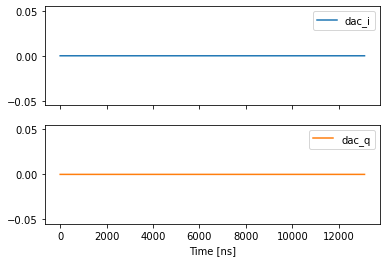

In [9]:
df_dac = ol.capture_dac_iq_df()
df_dac.plot(subplots=True);

In [10]:
df_adc = ol.capture_adc_iq_df()

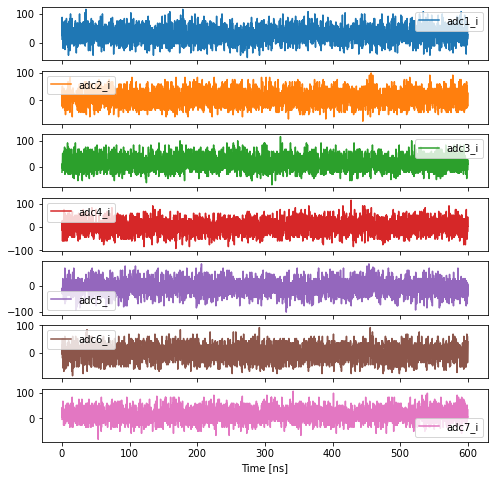

In [11]:
cols = [f'adc{ch}_i' for ch in range(1, 8)]
df_adc[cols][0:600].plot(subplots=True, figsize=(8, 8));